In [165]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Environment Ready!")

Environment Ready!


In [166]:

players = pd.read_csv("../data/players.csv")
national_teams = pd.read_csv("../data/national_teams.csv")
games = pd.read_csv("../data/games.csv")
competitions = pd.read_csv("../data/competitions.csv")

print("Players:", players.shape)
print("National Teams:", national_teams.shape)
print("Games:", games.shape)
print("Competitions:", competitions.shape)

Players: (47716, 26)
National Teams: (118, 17)
Games: (88808, 23)
Competitions: (67, 11)


In [167]:
national_teams.head()

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000.0,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000.0,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001.0,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...
3,13342,Guatemala,guatemala,58,Guatemala,GU1A,CONCACAF,https://tmssl.akamaized.net//images/flagge/hea...,21,25.2,6,28.6,5330000.0,NaN,96,2025,https://www.transfermarkt.co.uk/guatemala/star...
4,13497,Uganda,uganda,176,Uganda,UGL1,CAF,https://tmssl.akamaized.net//images/flagge/hea...,28,28.0,23,82.1,8700000.0,NaN,88,2025,https://www.transfermarkt.co.uk/uganda/startse...


# World Cup 2026 Prediction Project
## Data Loading and Inspection

In [168]:
players = pd.read_csv("../data/players.csv")
national_teams = pd.read_csv("../data/national_teams.csv")
games = pd.read_csv("../data/games.csv")
competitions = pd.read_csv("../data/competitions.csv")

In [169]:
print("=== PLAYERS ===")
players.info()

players.head(3)

=== PLAYERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47716 entries, 0 to 47715
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             47716 non-null  int64  
 1   first_name                            44621 non-null  object 
 2   last_name                             47716 non-null  object 
 3   name                                  47716 non-null  object 
 4   last_season                           47716 non-null  int64  
 5   current_club_id                       47716 non-null  int64  
 6   player_code                           47716 non-null  object 
 7   country_of_birth                      42551 non-null  object 
 8   city_of_birth                         42827 non-null  object 
 9   country_of_citizenship                47443 non-null  object 
 10  date_of_birth                         47667 non-null  object 
 11 

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0


In [170]:
print("=== NATIONAL TEAMS ===")
national_teams.info()

national_teams.head(3)

=== NATIONAL TEAMS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   national_team_id       118 non-null    int64  
 1   name                   118 non-null    object 
 2   team_code              118 non-null    object 
 3   country_id             118 non-null    int64  
 4   country_name           118 non-null    object 
 5   country_code           118 non-null    object 
 6   confederation          117 non-null    object 
 7   team_image_url         118 non-null    object 
 8   squad_size             118 non-null    int64  
 9   average_age            118 non-null    float64
 10  foreigners_number      118 non-null    int64  
 11  foreigners_percentage  113 non-null    float64
 12  total_market_value     115 non-null    float64
 13  coach_name             0 non-null      float64
 14  fifa_ranking           118 non-null

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000.0,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000.0,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001.0,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...


In [171]:
print("=== COMPETITIONS ===")
competitions.info()

competitions.head(3)

=== COMPETITIONS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   competition_id        67 non-null     object 
 1   competition_code      67 non-null     object 
 2   name                  67 non-null     object 
 3   sub_type              67 non-null     object 
 4   type                  67 non-null     object 
 5   country_id            67 non-null     int64  
 6   country_name          54 non-null     object 
 7   domestic_league_code  54 non-null     object 
 8   confederation         67 non-null     object 
 9   total_clubs           51 non-null     float64
 10  url                   67 non-null     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 5.9+ KB


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
0,A1,bundesliga,bundesliga,first_tier,domestic_league,127,Austria,A1,europa,12.0,https://www.transfermarkt.co.uk/bundesliga/sta...
1,AFAC,afc-asian-cup,afc-asian-cup,afc_asian_cup,national_team_competition,-1,NaN,NaN,asien,NaN,https://www.transfermarkt.co.uk/afc-asian-cup/...
2,AFCN,africa-cup-of-nations,africa-cup-of-nations,africa_cup_of_nations,national_team_competition,-1,NaN,NaN,afrika,NaN,https://www.transfermarkt.co.uk/africa-cup-of-...


In [172]:
national_teams.isnull().sum()

national_team_id           0
name                       0
team_code                  0
country_id                 0
country_name               0
country_code               0
confederation              1
team_image_url             0
squad_size                 0
average_age                0
foreigners_number          0
foreigners_percentage      5
total_market_value         3
coach_name               118
fifa_ranking               0
last_season                0
url                        0
dtype: int64

In [173]:
len(national_teams)

118

In [174]:
df = national_teams.copy()

df.head()

,national_team_id,name,team_code,country_id,country_name,country_code,confederation,team_image_url,squad_size,average_age,foreigners_number,foreigners_percentage,total_market_value,coach_name,fifa_ranking,last_season,url
0,10521,San Marino,san-marino,144,San Marino,SMR1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,24,24.9,17,70.8,995000.0,NaN,211,2025,https://www.transfermarkt.co.uk/san-marino/sta...
1,10533,Andorra,andorra,5,Andorra,AND2,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,29.2,11,42.3,3380000.0,NaN,173,2025,https://www.transfermarkt.co.uk/andorra/starts...
2,11953,Montenegro,montenegro,216,Montenegro,MNE1,UEFA,https://tmssl.akamaized.net//images/flagge/hea...,26,28.3,24,92.3,60130001.0,NaN,81,2025,https://www.transfermarkt.co.uk/montenegro/sta...
3,13342,Guatemala,guatemala,58,Guatemala,GU1A,CONCACAF,https://tmssl.akamaized.net//images/flagge/hea...,21,25.2,6,28.6,5330000.0,NaN,96,2025,https://www.transfermarkt.co.uk/guatemala/star...
4,13497,Uganda,uganda,176,Uganda,UGL1,CAF,https://tmssl.akamaized.net//images/flagge/hea...,28,28.0,23,82.1,8700000.0,NaN,88,2025,https://www.transfermarkt.co.uk/uganda/startse...


## Feature Engineering & Team Strength Rating

In [175]:
from sklearn.preprocessing import MinMaxScaler

In [176]:
df['total_market_value'] = df['total_market_value'].fillna(0)

In [177]:
df['total_market_value'].isnull().sum()

np.int64(0)

In [178]:
#Higher number = stronger team
max_ranking = df['fifa_ranking'].max()

df['inverse_fifa'] = (
    max_ranking - df['fifa_ranking']
) + 1

In [179]:
#Normalize FIFA Ranking
scaler = MinMaxScaler()

df['norm_fifa'] = scaler.fit_transform(
    df[['inverse_fifa']]
)

In [180]:
df[['name', 'fifa_ranking', 'norm_fifa']].head()

,name,fifa_ranking,norm_fifa
0,San Marino,211,0.000000
1,Andorra,173,0.180952
2,Montenegro,81,0.619048
3,Guatemala,96,0.547619
4,Uganda,88,0.585714


In [181]:
#Normalize Market Value
df['norm_value'] = scaler.fit_transform(
    df[['total_market_value']]
)

In [182]:
df[['name', 'total_market_value', 'norm_value']].head()

,name,total_market_value,norm_value
0,San Marino,995000.0,0.001151
1,Andorra,3380000.0,0.003910
2,Montenegro,60130001.0,0.069555
3,Guatemala,5330000.0,0.006165
4,Uganda,8700000.0,0.010064


In [183]:
df['team_rating'] = (
    df['norm_fifa'] * 0.4
    +
    df['norm_value'] * 0.6
)

In [184]:
df[
    [
        'name',
        'fifa_ranking',
        'total_market_value',
        'team_rating'
    ]
].head()

,name,fifa_ranking,total_market_value,team_rating
0,San Marino,211,995000.0,0.000691
1,Andorra,173,3380000.0,0.074727
2,Montenegro,81,60130001.0,0.289352
3,Guatemala,96,5330000.0,0.222747
4,Uganda,88,8700000.0,0.240324


In [185]:
top20 = df.sort_values(
    by='team_rating',
    ascending=False
)[
    [
        'name',
        'fifa_ranking',
        'total_market_value',
        'team_rating'
    ]
].head(20)

top20

,name,fifa_ranking,total_market_value,team_rating
29,Portugal,5,864500000.0,0.992381
31,Italy,12,833500000.0,0.957532
46,Brazil,6,778500000.0,0.930789
44,Argentina,3,761200012.0,0.924496
34,Netherlands,7,766000000.0,0.920208
27,Germany,10,773500000.0,0.919699
37,Belgium,9,534200012.0,0.755520
59,Senegal,14,474000000.0,0.704214
72,Morocco,8,456000000.0,0.703150
47,Norway,31,504000000.0,0.692655


In [186]:
top20_display = top20.copy()

top20_display['total_market_value'] = (
    top20_display['total_market_value']
    .apply(
        lambda x:
        f"€{x/1e6:.1f}M"
        if x < 1e9
        else f"€{x/1e9:.2f}B"
    )
)

top20_display

,name,fifa_ranking,total_market_value,team_rating
29,Portugal,5,€864.5M,0.992381
31,Italy,12,€833.5M,0.957532
46,Brazil,6,€778.5M,0.930789
44,Argentina,3,€761.2M,0.924496
34,Netherlands,7,€766.0M,0.920208
27,Germany,10,€773.5M,0.919699
37,Belgium,9,€534.2M,0.755520
59,Senegal,14,€474.0M,0.704214
72,Morocco,8,€456.0M,0.703150
47,Norway,31,€504.0M,0.692655


In [187]:
df.to_csv(
    "../outputs/national_teams_with_ratings.csv",
    index=False
)

In [188]:
def prepare_team_data(df):

    mapping = {
        'czech republic': 'czechia',
        'republic of ireland': 'ireland',
        'united states': 'usa',
        'south korea': 'republic of korea',
        'ivory coast': "côte d'ivoire",
        'netherlands': 'netherlands',
        'turkiye': 'turkiye'
    }

    def clean_name(name):
        n = str(name).strip().lower()
        return mapping.get(n, n)

    df = df.copy()
    df['name_clean'] = df['name'].apply(clean_name)

    return df

In [189]:
df_ratings = prepare_team_data(df)

df_ratings[['name', 'name_clean']].head()

,name,name_clean
0,San Marino,san marino
1,Andorra,andorra
2,Montenegro,montenegro
3,Guatemala,guatemala
4,Uganda,uganda


In [190]:
import numpy as np

def match_probabilities(team_a, team_b, df_data):

    team_a = str(team_a).strip().lower()
    team_b = str(team_b).strip().lower()

    row_a = df_data[df_data['name_clean'] == team_a]
    row_b = df_data[df_data['name_clean'] == team_b]

    default_rating = df_data['team_rating'].median()

    rating_a = (
        row_a['team_rating'].values[0]
        if not row_a.empty
        else default_rating
    )

    rating_b = (
        row_b['team_rating'].values[0]
        if not row_b.empty
        else default_rating
    )

    diff = rating_a - rating_b

    gamma = 5

    prob_a_base = 1 / (1 + np.exp(-gamma * diff))

    prob_draw = 0.28 * np.exp(-abs(gamma * diff))

    prob_a = prob_a_base * (1 - prob_draw)

    prob_b = (1 - prob_a_base) * (1 - prob_draw)

    return prob_a, prob_draw, prob_b

In [191]:
match_probabilities(
    "brazil",
    "argentina",
    df_ratings
)

(np.float64(0.3700674037237674),
 np.float64(0.2713274438111877),
 np.float64(0.35860515246504493))

In [192]:
def simulate_group_match(team_a, team_b, df_data):

    p_a, p_draw, p_b = match_probabilities(
        team_a,
        team_b,
        df_data
    )

    result = np.random.choice(
        ['A', 'DRAW', 'B'],
        p=[p_a, p_draw, p_b]
    )

    return result

In [193]:
simulate_group_match(
    "brazil",
    "argentina",
    df_ratings
)

np.str_('DRAW')

In [194]:
results = []

for _ in range(20):

    results.append(
        simulate_group_match(
            "brazil",
            "argentina",
            df_ratings
        )
    )

results

[np.str_('DRAW'),
 np.str_('DRAW'),
 np.str_('A'),
 np.str_('A'),
 np.str_('DRAW'),
 np.str_('B'),
 np.str_('B'),
 np.str_('DRAW'),
 np.str_('B'),
 np.str_('DRAW'),
 np.str_('DRAW'),
 np.str_('A'),
 np.str_('A'),
 np.str_('B'),
 np.str_('A'),
 np.str_('DRAW'),
 np.str_('B'),
 np.str_('A'),
 np.str_('B'),
 np.str_('DRAW')]

In [195]:
p_a, p_draw, p_b = match_probabilities(
    "brazil",
    "argentina",
    df_ratings
)

print("Brazil Win :", round(p_a * 100, 2), "%")
print("Draw       :", round(p_draw * 100, 2), "%")
print("Argentina  :", round(p_b * 100, 2), "%")

Brazil Win : 37.01 %
Draw       : 27.13 %
Argentina  : 35.86 %


In [196]:
def simulate_group_stage(groups, df_data):

    final_tables = {}

    for group_name, teams in groups.items():

        points = {
            team: 0
            for team in teams
        }

        for i in range(len(teams)):

            for j in range(i + 1, len(teams)):

                team1 = teams[i]
                team2 = teams[j]

                p_win, p_draw, p_loss = match_probabilities(
                    team1,
                    team2,
                    df_data
                )

                result = np.random.choice(
                    ['TEAM1', 'DRAW', 'TEAM2'],
                    p=[p_win, p_draw, p_loss]
                )

                if result == 'TEAM1':
                    points[team1] += 3

                elif result == 'DRAW':
                    points[team1] += 1
                    points[team2] += 1

                else:
                    points[team2] += 3

        standings = sorted(
            points.items(),
            key=lambda x: x[1],
            reverse=True
        )

        final_tables[group_name] = standings

    return final_tables

In [197]:
test_group = {
    "Group A": [
        "Brazil",
        "Argentina",
        "Germany",
        "Japan"
    ]
}

In [198]:
results = simulate_group_stage(
    test_group,
    df_ratings
)

results

{'Group A': [('Germany', 7), ('Brazil', 5), ('Argentina', 4), ('Japan', 0)]}

In [199]:
for group, table in results.items():

    print(f"\n{group}")

    for pos, (team, pts) in enumerate(table, start=1):

        print(
            f"{pos}. {team:<15} {pts} pts"
        )


Group A
1. Germany         7 pts
2. Brazil          5 pts
3. Argentina       4 pts
4. Japan           0 pts


In [200]:
groups_2026 = {

    'Group A': [
        'Mexico',
        'South Africa',
        'South Korea',
        'Czechia'
    ],

    'Group B': [
        'Canada',
        'Switzerland',
        'Qatar',
        'Bosnia and Herzegovina'
    ],

    'Group C': [
        'Brazil',
        'Morocco',
        'Haiti',
        'Scotland'
    ],

    'Group D': [
        'USA',
        'Paraguay',
        'Australia',
        'Turkiye'
    ],

    'Group E': [
        'Germany',
        'Curacao',
        'Ivory Coast',
        'Ecuador'
    ],

    'Group F': [
        'Netherlands',
        'Japan',
        'Tunisia',
        'Sweden'
    ],

    'Group G': [
        'Belgium',
        'Egypt',
        'Iran',
        'New Zealand'
    ],

    'Group H': [
        'Spain',
        'Cabo Verde',
        'Saudi Arabia',
        'Uruguay'
    ],

    'Group I': [
        'France',
        'Senegal',
        'Norway',
        'Iraq'
    ],

    'Group J': [
        'Argentina',
        'Algeria',
        'Austria',
        'Jordan'
    ],

    'Group K': [
        'Portugal',
        'Uzbekistan',
        'Colombia',
        'Congo DR'
    ],

    'Group L': [
        'England',
        'Croatia',
        'Ghana',
        'Panama'
    ]
}

In [201]:
group_results = simulate_group_stage(
    groups_2026,
    df_ratings
)

In [202]:
for group, standings in group_results.items():

    print("\n" + "=" * 40)
    print(group)
    print("=" * 40)

    for pos, (team, pts) in enumerate(
        standings,
        start=1
    ):

        print(
            f"{pos}. {team:<22} {pts} pts"
        )


Group A
1. Mexico                 6 pts
2. Czechia                6 pts
3. South Africa           4 pts
4. South Korea            1 pts

Group B
1. Qatar                  7 pts
2. Switzerland            5 pts
3. Bosnia and Herzegovina 3 pts
4. Canada                 1 pts

Group C
1. Brazil                 9 pts
2. Morocco                6 pts
3. Scotland               3 pts
4. Haiti                  0 pts

Group D
1. Australia              9 pts
2. USA                    6 pts
3. Turkiye                3 pts
4. Paraguay               0 pts

Group E
1. Germany                9 pts
2. Ecuador                6 pts
3. Ivory Coast            3 pts
4. Curacao                0 pts

Group F
1. Netherlands            9 pts
2. Japan                  4 pts
3. Sweden                 4 pts
4. Tunisia                0 pts

Group G
1. Iran                   7 pts
2. Egypt                  5 pts
3. Belgium                4 pts
4. New Zealand            0 pts

Group H
1. Uruguay                9 pts


In [203]:
group_results

{'Group A': [('Mexico', 6),
  ('Czechia', 6),
  ('South Africa', 4),
  ('South Korea', 1)],
 'Group B': [('Qatar', 7),
  ('Switzerland', 5),
  ('Bosnia and Herzegovina', 3),
  ('Canada', 1)],
 'Group C': [('Brazil', 9), ('Morocco', 6), ('Scotland', 3), ('Haiti', 0)],
 'Group D': [('Australia', 9), ('USA', 6), ('Turkiye', 3), ('Paraguay', 0)],
 'Group E': [('Germany', 9),
  ('Ecuador', 6),
  ('Ivory Coast', 3),
  ('Curacao', 0)],
 'Group F': [('Netherlands', 9), ('Japan', 4), ('Sweden', 4), ('Tunisia', 0)],
 'Group G': [('Iran', 7), ('Egypt', 5), ('Belgium', 4), ('New Zealand', 0)],
 'Group H': [('Uruguay', 9),
  ('Spain', 6),
  ('Cabo Verde', 3),
  ('Saudi Arabia', 0)],
 'Group I': [('Norway', 9), ('France', 3), ('Senegal', 3), ('Iraq', 3)],
 'Group J': [('Argentina', 6), ('Algeria', 6), ('Jordan', 4), ('Austria', 1)],
 'Group K': [('Portugal', 9),
  ('Colombia', 6),
  ('Congo DR', 3),
  ('Uzbekistan', 0)],
 'Group L': [('Ghana', 7), ('Panama', 5), ('Croatia', 3), ('England', 1)]}

In [204]:
def simulate_knockout_match(team1, team2, df_data):

    team1_data = df_data[
        df_data['name_clean'] == team1.lower()
    ]

    team2_data = df_data[
        df_data['name_clean'] == team2.lower()
    ]

    default_rating = df_data['team_rating'].median()

    rating1 = (
        team1_data['team_rating'].values[0]
        if not team1_data.empty
        else default_rating
    )

    rating2 = (
        team2_data['team_rating'].values[0]
        if not team2_data.empty
        else default_rating
    )

    diff = rating1 - rating2

    probability_team1 = (
        1 /
        (1 + np.exp(-5 * diff))
    )

    probability_team2 = (
        1 - probability_team1
    )

    winner = np.random.choice(
        [team1, team2],
        p=[
            probability_team1,
            probability_team2
        ]
    )

    return winner

In [205]:
import pandas as pd

def get_qualified_teams(
    group_results,
    df_data
):

    first_place = {}
    second_place = {}

    third_place = []

    for group, standings in group_results.items():

        first_place[group] = standings[0][0]
        second_place[group] = standings[1][0]

        team_3rd = standings[2][0]
        points_3rd = standings[2][1]

        rating_3rd = (
            df_data[
                df_data['name_clean']
                ==
                team_3rd.lower()
            ]['team_rating']
            .values[0]
            if team_3rd.lower()
            in df_data['name_clean'].values
            else 0
        )

        third_place.append({
            'team': team_3rd,
            'points': points_3rd,
            'rating': rating_3rd
        })

    third_df = pd.DataFrame(
        third_place
    )

    third_df = third_df.sort_values(
        by=['points', 'rating'],
        ascending=False
    )

    best_thirds = list(
        third_df['team'].head(8)
    )

    qualified = (
        list(first_place.values())
        +
        list(second_place.values())
        +
        best_thirds
    )

    return qualified

In [206]:
qualified_teams = get_qualified_teams(
    group_results,
    df_ratings
)

len(qualified_teams)

32

In [207]:
def run_knockout_stage(
    qualified_teams,
    df_data
):

    teams = qualified_teams.copy()

    np.random.shuffle(teams)

    rounds = [
        "Round of 32",
        "Round of 16",
        "Quarterfinals",
        "Semifinals",
        "Final"
    ]

    for round_name in rounds:

        print("\n")
        print("=" * 50)
        print(round_name)
        print("=" * 50)

        winners = []

        for i in range(
            0,
            len(teams),
            2
        ):

            team1 = teams[i]
            team2 = teams[i + 1]

            winner = simulate_knockout_match(
                team1,
                team2,
                df_data
            )

            print(
                f"{team1} vs {team2} -> {winner}"
            )

            winners.append(winner)

        teams = winners

        if len(teams) == 1:

            print("\n")
            print(
                f"🏆 Champion: {teams[0]}"
            )

            return teams[0]

In [208]:
champion = run_knockout_stage(
    qualified_teams,
    df_ratings
)



Round of 32
Belgium vs Norway -> Belgium
Turkiye vs Mexico -> Mexico
Japan vs Ecuador -> Japan
Brazil vs Colombia -> Brazil
Scotland vs France -> Scotland
Australia vs Senegal -> Senegal
Croatia vs South Africa -> Croatia
Sweden vs Germany -> Germany
Switzerland vs Ghana -> Ghana
Egypt vs Uruguay -> Egypt
Argentina vs Czechia -> Argentina
Spain vs Portugal -> Portugal
USA vs Morocco -> Morocco
Panama vs Qatar -> Panama
Iran vs Algeria -> Algeria
Netherlands vs Jordan -> Netherlands


Round of 16
Belgium vs Mexico -> Mexico
Japan vs Brazil -> Brazil
Scotland vs Senegal -> Scotland
Croatia vs Germany -> Germany
Ghana vs Egypt -> Egypt
Argentina vs Portugal -> Argentina
Morocco vs Panama -> Morocco
Algeria vs Netherlands -> Algeria


Quarterfinals
Mexico vs Brazil -> Brazil
Scotland vs Germany -> Germany
Egypt vs Argentina -> Argentina
Morocco vs Algeria -> Morocco


Semifinals
Brazil vs Germany -> Brazil
Argentina vs Morocco -> Argentina


Final
Brazil vs Argentina -> Argentina


🏆 Cha

In [209]:
def run_full_world_cup(
    groups,
    df_data
):

    group_results = simulate_group_stage(
        groups,
        df_data
    )

    qualified = get_qualified_teams(
        group_results,
        df_data
    )

    champion = run_knockout_stage(
        qualified,
        df_data
    )

    return champion

In [210]:
champion = run_full_world_cup(
    groups_2026,
    df_ratings
)

print(champion)



Round of 32
Morocco vs Argentina -> Argentina
Tunisia vs Czechia -> Czechia
Uzbekistan vs Scotland -> Scotland
Netherlands vs Iraq -> Netherlands
Qatar vs Turkiye -> Turkiye
USA vs Iran -> USA
Egypt vs Croatia -> Croatia
Ghana vs Algeria -> Algeria
Germany vs Spain -> Germany
Norway vs Paraguay -> Norway
Saudi Arabia vs Switzerland -> Saudi Arabia
Colombia vs Curacao -> Colombia
Senegal vs Sweden -> Sweden
Belgium vs Panama -> Belgium
South Korea vs Brazil -> Brazil
Portugal vs Mexico -> Portugal


Round of 16
Argentina vs Czechia -> Argentina
Scotland vs Netherlands -> Netherlands
Turkiye vs USA -> USA
Croatia vs Algeria -> Croatia
Germany vs Norway -> Germany
Saudi Arabia vs Colombia -> Colombia
Sweden vs Belgium -> Belgium
Brazil vs Portugal -> Brazil


Quarterfinals
Argentina vs Netherlands -> Netherlands
USA vs Croatia -> USA
Germany vs Colombia -> Germany
Belgium vs Brazil -> Belgium


Semifinals
Netherlands vs USA -> Netherlands
Germany vs Belgium -> Germany


Final
Netherland

In [211]:
run_full_world_cup(
    groups_2026,
    df_ratings
)



Round of 32
Netherlands vs Canada -> Netherlands
Algeria vs Spain -> Spain
Curacao vs Colombia -> Colombia
Czechia vs Belgium -> Belgium
Turkiye vs Sweden -> Turkiye
South Korea vs Ghana -> Ghana
Portugal vs Germany -> Portugal
Switzerland vs South Africa -> Switzerland
Argentina vs Brazil -> Brazil
Uruguay vs USA -> Uruguay
Egypt vs Iraq -> Egypt
Senegal vs Norway -> Senegal
Ecuador vs Tunisia -> Tunisia
Australia vs Bosnia and Herzegovina -> Australia
Austria vs Morocco -> Morocco
Iran vs Croatia -> Croatia


Round of 16
Netherlands vs Spain -> Netherlands
Colombia vs Belgium -> Belgium
Turkiye vs Ghana -> Turkiye
Portugal vs Switzerland -> Portugal
Brazil vs Uruguay -> Brazil
Egypt vs Senegal -> Senegal
Tunisia vs Australia -> Tunisia
Morocco vs Croatia -> Morocco


Quarterfinals
Netherlands vs Belgium -> Belgium
Turkiye vs Portugal -> Portugal
Brazil vs Senegal -> Senegal
Tunisia vs Morocco -> Morocco


Semifinals
Belgium vs Portugal -> Portugal
Senegal vs Morocco -> Senegal


Fi

np.str_('Senegal')

### Monte Carlo Simulation

In [212]:
def run_knockout_silent(
    qualified_teams,
    df_data
):

    teams = qualified_teams.copy()

    np.random.shuffle(teams)

    while len(teams) > 1:

        winners = []

        for i in range(
            0,
            len(teams),
            2
        ):

            winner = simulate_knockout_match(
                teams[i],
                teams[i + 1],
                df_data
            )

            winners.append(winner)

        teams = winners

    return teams[0]

In [213]:
def simulate_world_cup(
    groups,
    df_data
):

    group_results = simulate_group_stage(
        groups,
        df_data
    )

    qualified = get_qualified_teams(
        group_results,
        df_data
    )

    champion = run_knockout_silent(
        qualified,
        df_data
    )

    return champion

In [214]:
champion = simulate_world_cup(
    groups_2026,
    df_ratings
)

print(champion)

Netherlands


In [215]:
def monte_carlo_world_cup(
    groups,
    df_data,
    n_simulations=10000
):

    champions = {}

    print(
        f"Running {n_simulations} simulations..."
    )

    for i in range(n_simulations):

        if (i + 1) % 100 == 0:

            print(
                f"Completed {i+1} simulations"
            )

        champion = simulate_world_cup(
            groups,
            df_data
        )

        champions[champion] = (
            champions.get(champion, 0)
            + 1
        )

    return champions

In [216]:
champions_count = monte_carlo_world_cup(
    groups_2026,
    df_ratings,
    n_simulations=10000
)

Running 10000 simulations...
Completed 100 simulations
Completed 200 simulations
Completed 300 simulations
Completed 400 simulations
Completed 500 simulations
Completed 600 simulations
Completed 700 simulations
Completed 800 simulations
Completed 900 simulations
Completed 1000 simulations
Completed 1100 simulations
Completed 1200 simulations
Completed 1300 simulations
Completed 1400 simulations
Completed 1500 simulations
Completed 1600 simulations
Completed 1700 simulations
Completed 1800 simulations
Completed 1900 simulations
Completed 2000 simulations
Completed 2100 simulations
Completed 2200 simulations
Completed 2300 simulations
Completed 2400 simulations
Completed 2500 simulations
Completed 2600 simulations
Completed 2700 simulations
Completed 2800 simulations
Completed 2900 simulations
Completed 3000 simulations
Completed 3100 simulations
Completed 3200 simulations
Completed 3300 simulations
Completed 3400 simulations
Completed 3500 simulations
Completed 3600 simulations
Complete

In [252]:
results_df = pd.DataFrame(
    list(champions_count.items()),
    columns=[
        "Team",
        "Titles"
    ]
)

results_df[
    "Title Probability (%)"
] = (
    results_df["Titles"]
    /
    10000
) * 100

In [253]:
results_df = results_df.sort_values(
    by="Title Probability (%)",
    ascending=False
)

results_df.head(20)

,Team,Titles,Title Probability (%)
1,Portugal,2574,25.74
5,Brazil,1626,16.26
3,Argentina,1547,15.47
0,Netherlands,1533,15.33
2,Germany,1471,14.71
9,Belgium,308,3.08
12,Senegal,173,1.73
4,Morocco,168,1.68
13,Norway,146,1.46
8,Turkiye,110,1.10


In [254]:
results_df[
    "Title Probability (%)"
] = (
    results_df[
        "Title Probability (%)"
    ]
    .round(2)
)

In [255]:
results_df

,Team,Titles,Title Probability (%)
1,Portugal,2574,25.74
5,Brazil,1626,16.26
3,Argentina,1547,15.47
0,Netherlands,1533,15.33
2,Germany,1471,14.71
9,Belgium,308,3.08
12,Senegal,173,1.73
4,Morocco,168,1.68
13,Norway,146,1.46
8,Turkiye,110,1.10


In [256]:
results_df.to_csv(
    "../outputs/world_cup_2026_probabilities.csv",
    index=False
)

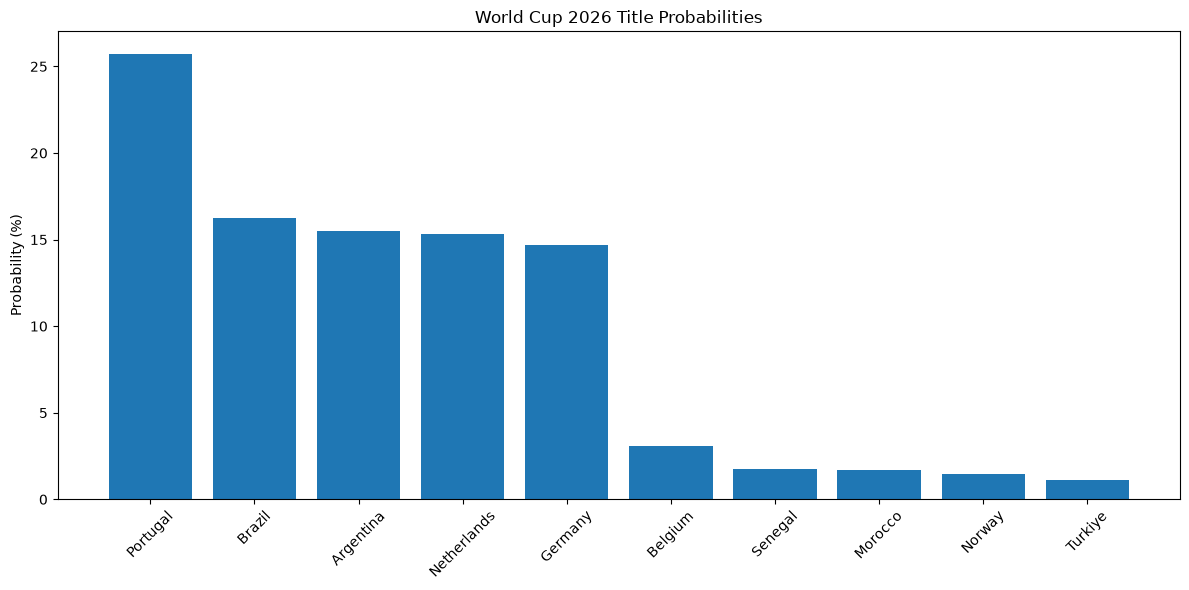

In [257]:
import matplotlib.pyplot as plt

top10 = results_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xticks(rotation=45)

plt.ylabel(
    "Probability (%)"
)

plt.title(
    "World Cup 2026 Title Probabilities"
)

plt.tight_layout()

plt.show()

## Create a Score Generator

In [258]:
def generate_match_score(
    team_a,
    team_b,
    df_data
):
    
    p_a, p_draw, p_b = match_probabilities(
        team_a,
        team_b,
        df_data
    )

    result = np.random.choice(
        ["A", "DRAW", "B"],
        p=[p_a, p_draw, p_b]
    )

    if result == "DRAW":

        goals = np.random.choice(
            [0, 1, 2, 3],
            p=[0.20, 0.45, 0.25, 0.10]
        )

        return goals, goals

    elif result == "A":

        goals_a = np.random.choice(
            [1,2,3,4,5],
            p=[0.30,0.35,0.20,0.10,0.05]
        )

        goals_b = np.random.randint(
            0,
            goals_a
        )

        return goals_a, goals_b

    else:

        goals_b = np.random.choice(
            [1,2,3,4,5],
            p=[0.30,0.35,0.20,0.10,0.05]
        )

        goals_a = np.random.randint(
            0,
            goals_b
        )

        return goals_a, goals_b

In [259]:
for _ in range(10):
    print(
        generate_match_score(
            "Brazil",
            "Argentina",
            df_ratings
        )
    )

(np.int64(1), 0)
(np.int64(1), 0)
(np.int64(1), np.int64(1))
(0, np.int64(1))
(0, np.int64(3))
(np.int64(1), 0)
(np.int64(2), 0)
(np.int64(3), 1)
(np.int64(1), 0)
(0, np.int64(1))


In [260]:
def create_group_table(teams):

    table = {}

    for team in teams:

        table[team] = {

            "points": 0,
            "gf": 0,
            "ga": 0,
            "gd": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0
        }

    return table

In [261]:
def simulate_group_stage_realistic(
    groups,
    df_data
):

    all_groups = {}

    for group_name, teams in groups.items():

        table = create_group_table(
            teams
        )

        for i in range(len(teams)):

            for j in range(i + 1, len(teams)):

                team1 = teams[i]
                team2 = teams[j]

                g1, g2 = generate_match_score(
                    team1,
                    team2,
                    df_data
                )

                table[team1]["gf"] += g1
                table[team1]["ga"] += g2

                table[team2]["gf"] += g2
                table[team2]["ga"] += g1

                if g1 > g2:

                    table[team1]["points"] += 3
                    table[team1]["wins"] += 1
                    table[team2]["losses"] += 1

                elif g2 > g1:

                    table[team2]["points"] += 3
                    table[team2]["wins"] += 1
                    table[team1]["losses"] += 1

                else:

                    table[team1]["points"] += 1
                    table[team2]["points"] += 1

                    table[team1]["draws"] += 1
                    table[team2]["draws"] += 1

        for team in teams:

            table[team]["gd"] = (
                table[team]["gf"]
                -
                table[team]["ga"]
            )

        standings = sorted(
            table.items(),
            key=lambda x: (
                x[1]["points"],
                x[1]["gd"],
                x[1]["gf"]
            ),
            reverse=True
        )

        all_groups[group_name] = standings

    return all_groups

In [262]:
results = simulate_group_stage_realistic(
    {
        "Group A":[
            "Brazil",
            "Argentina",
            "Germany",
            "Japan"
        ]
    },
    df_ratings
)

In [263]:
results

{'Group A': [('Germany',
   {'points': 7,
    'gf': np.int64(8),
    'ga': np.int64(3),
    'gd': np.int64(5),
    'wins': 2,
    'draws': 1,
    'losses': 0}),
  ('Argentina',
   {'points': 5,
    'gf': np.int64(3),
    'ga': np.int64(1),
    'gd': np.int64(2),
    'wins': 1,
    'draws': 2,
    'losses': 0}),
  ('Brazil',
   {'points': 3,
    'gf': np.int64(5),
    'ga': np.int64(9),
    'gd': np.int64(-4),
    'wins': 1,
    'draws': 0,
    'losses': 2}),
  ('Japan',
   {'points': 1,
    'gf': np.int64(4),
    'ga': np.int64(7),
    'gd': np.int64(-3),
    'wins': 0,
    'draws': 1,
    'losses': 2})]}

In [264]:
for group, standings in results.items():

    print(f"\n{group}")

    for pos, (team, stats) in enumerate(
        standings,
        start=1
    ):

        print(
            f"{pos}. {team:<15}"
            f" Pts:{stats['points']}"
            f" GD:{stats['gd']}"
            f" GF:{stats['gf']}"
        )


Group A
1. Germany         Pts:7 GD:5 GF:8
2. Argentina       Pts:5 GD:2 GF:3
3. Brazil          Pts:3 GD:-4 GF:5
4. Japan           Pts:1 GD:-3 GF:4


In [265]:
HOSTS = [
    "usa",
    "canada",
    "mexico"
]

def apply_home_advantage(
    team_name,
    rating
):
    
    if team_name.lower() in HOSTS:
        return rating * 1.05
    
    return rating

In [266]:
def match_probabilities(
    team_a,
    team_b,
    df_data=None
):

    rating_a = get_rating(team_a)
    rating_b = get_rating(team_b)

    rating_a = apply_home_advantage(
        team_a,
        rating_a
    )

    rating_b = apply_home_advantage(
        team_b,
        rating_b
    )

    diff = rating_a - rating_b

    gamma = 5

    prob_a_base = (
        1 /
        (1 + np.exp(-gamma * diff))
    )

    prob_draw = (
        0.28 *
        np.exp(-abs(gamma * diff))
    )

    prob_a = prob_a_base * (
        1 - prob_draw
    )

    prob_b = (
        1 - prob_a_base
    ) * (
        1 - prob_draw
    )

    return prob_a, prob_draw, prob_b

In [267]:
match_probabilities(
    "USA",
    "Brazil",
    df_ratings
)

(np.float64(0.1835913879166543),
 np.float64(0.06875597881895622),
 np.float64(0.7476526332643895))

In [268]:
match_probabilities(
    "Canada",
    "Germany",
    df_ratings
)

(np.float64(0.08724296935026814),
 np.float64(0.027597314906687848),
 np.float64(0.8851597157430441))

In [269]:
def expected_goals(
    rating
):
    
    return (
        0.8
        +
        2.2 * rating
    )

In [270]:
expected_goals(0.95)

2.8899999999999997

## Generate Goals from Poisson Distribution

In [271]:
def generate_realistic_goals(
    team_a_rating,
    team_b_rating
):

    goals_a = np.random.poisson(
        expected_goals(team_a_rating)
    )

    goals_b = np.random.poisson(
        expected_goals(team_b_rating)
    )

    return goals_a, goals_b

In [272]:
results_df["Std Error"] = np.sqrt(
    (
        results_df["Title Probability (%)"]/100
    )
    *
    (
        1 -
        results_df["Title Probability (%)"]/100
    )
    /
    1000
)

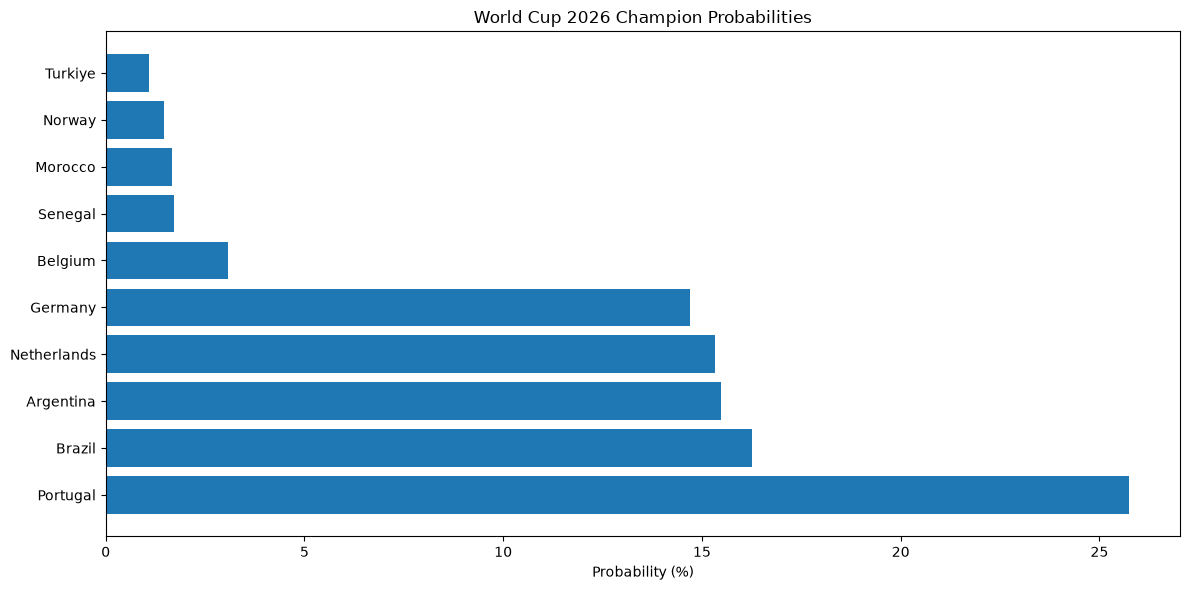

In [273]:
import matplotlib.pyplot as plt

top10 = results_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xlabel(
    "Probability (%)"
)

plt.title(
    "World Cup 2026 Champion Probabilities"
)

plt.tight_layout()

plt.show()

In [274]:
qualified_teams = (
    df_ratings
    .sort_values(
        "team_rating",
        ascending=False
    )
    .head(48)
)

qualified_teams[
    ["name", "team_rating"]
]

,name,team_rating
29,Portugal,0.992381
31,Italy,0.957532
46,Brazil,0.930789
44,Argentina,0.924496
34,Netherlands,0.920208
27,Germany,0.919699
37,Belgium,0.755520
59,Senegal,0.704214
72,Morocco,0.703150
47,Norway,0.692655


In [275]:
pots = np.array_split(
    qualified_teams["name"].tolist(),
    12
)

In [276]:
for i, pot in enumerate(pots, start=1):
    print(f"Pot {i}")
    print(list(pot))
    print()

Pot 1
[np.str_('Portugal'), np.str_('Italy'), np.str_('Brazil'), np.str_('Argentina')]

Pot 2
[np.str_('Netherlands'), np.str_('Germany'), np.str_('Belgium'), np.str_('Senegal')]

Pot 3
[np.str_('Morocco'), np.str_('Norway'), np.str_('Turkiye'), np.str_('Denmark')]

Pot 4
[np.str_('Uruguay'), np.str_('United States'), np.str_('Ecuador'), np.str_('Switzerland')]

Pot 5
[np.str_('Colombia'), np.str_('Sweden'), np.str_('Croatia'), np.str_('Japan')]

Pot 6
[np.str_('Austria'), np.str_('Serbia'), np.str_('Ukraine'), np.str_('Greece')]

Pot 7
[np.str_('Algeria'), np.str_('Nigeria'), np.str_('Poland'), np.str_('Russia')]

Pot 8
[np.str_('Wales'), np.str_('Hungary'), np.str_('Scotland'), np.str_('South Korea')]

Pot 9
[np.str_('Czech Republic'), np.str_('Canada'), np.str_('Mexico'), np.str_('Egypt')]

Pot 10
[np.str_('Paraguay'), np.str_('Republic of Ireland'), np.str_('Slovakia'), np.str_('Georgia')]

Pot 11
[np.str_('France'), np.str_('Ghana'), np.str_('Spain'), np.str_('England')]

Pot 12
[

In [277]:
import random

def generate_random_groups(
    qualified_df
):

    teams = qualified_df["name"].tolist()

    random.shuffle(teams)

    groups = {}

    letters = [
        "A","B","C","D",
        "E","F","G","H",
        "I","J","K","L"
    ]

    for i in range(12):

        groups[f"Group {letters[i]}"] = (
            teams[i*4:(i+1)*4]
        )

    return groups

In [278]:
groups_auto = generate_random_groups(
    qualified_teams
)

groups_auto

{'Group A': ['Serbia', 'Georgia', 'Greece', 'Ecuador'],
 'Group B': ['Sweden', 'Bosnia-Herzegovina', 'Switzerland', 'Nigeria'],
 'Group C': ['Russia', 'Uruguay', 'Mexico', 'Portugal'],
 'Group D': ['Poland', 'Colombia', 'Paraguay', 'Norway'],
 'Group E': ['Turkiye', 'Republic of Ireland', 'Spain', 'Czech Republic'],
 'Group F': ['Netherlands', 'Hungary', 'Japan', 'Austria'],
 'Group G': ['Iran', 'Senegal', 'Egypt', 'Slovenia'],
 'Group H': ['Denmark', 'Argentina', 'Australia', 'England'],
 'Group I': ['Italy', 'Scotland', 'Belgium', 'South Korea'],
 'Group J': ['Canada', 'Croatia', 'Ukraine', 'Algeria'],
 'Group K': ['Morocco', 'Ghana', 'United States', 'Slovakia'],
 'Group L': ['Wales', 'France', 'Germany', 'Brazil']}

In [295]:
df_ratings = prepare_team_data(df)
rating_dict = dict(
    zip(
        df_ratings["name_clean"],
        df_ratings["team_rating"]
    )
)

In [280]:
rating_dict["brazil"]

0.9307885097358782

In [281]:
def get_rating(team_name):

    return rating_dict.get(
        str(team_name).lower(),
        np.median(
            list(rating_dict.values())
        )
    )

In [282]:
get_rating("brazil")

0.9307885097358782

In [283]:
DEFAULT_RATING = np.median(
    list(rating_dict.values())
)

In [284]:
def get_rating(team_name):

    return rating_dict.get(
        str(team_name).lower(),
        DEFAULT_RATING
    )

In [285]:
import time

start = time.time()

for _ in range(10000):

    match_probabilities(
        "brazil",
        "argentina"
    )

end = time.time()

print(
    "Execution Time:",
    end - start
)

Execution Time: 0.09098649024963379


In [286]:
tournament_stats = {}

In [287]:
df_ratings.sort_values(
    "team_rating",
    ascending=False
)[
    ["name", "team_rating"]
].head(20)

,name,team_rating
29,Portugal,0.992381
31,Italy,0.957532
46,Brazil,0.930789
44,Argentina,0.924496
34,Netherlands,0.920208
27,Germany,0.919699
37,Belgium,0.755520
59,Senegal,0.704214
72,Morocco,0.703150
47,Norway,0.692655


In [288]:
match_probabilities(
    "Portugal",
    "San Marino"
)

(np.float64(0.9910722516654267),
 np.float64(0.001966662029168827),
 np.float64(0.006961086305404531))

In [289]:
match_probabilities(
    "Brazil",
    "Argentina"
)

(np.float64(0.3700674037237674),
 np.float64(0.2713274438111877),
 np.float64(0.35860515246504493))

In [290]:
results_df.head(10)


,Team,Titles,Title Probability (%),Std Error
1,Portugal,2574,25.74,0.013826
5,Brazil,1626,16.26,0.011669
3,Argentina,1547,15.47,0.011435
0,Netherlands,1533,15.33,0.011393
2,Germany,1471,14.71,0.011201
9,Belgium,308,3.08,0.005464
12,Senegal,173,1.73,0.004123
4,Morocco,168,1.68,0.004064
13,Norway,146,1.46,0.003793
8,Turkiye,110,1.10,0.003298


In [291]:
results_df[
    "Title Probability (%)"
].sum()

np.float64(100.00000000000001)

In [292]:
missing = []

for team in groups_2026.values():

    for t in team:

        if str(t).lower() not in rating_dict:

            missing.append(t)

missing

['South Korea',
 'Bosnia and Herzegovina',
 'Haiti',
 'Curacao',
 'Ivory Coast',
 'Cabo Verde',
 'Congo DR']

In [296]:
name_mapping = {

    "usa": "united states",

    "south korea": "republic of korea",

    "ivory coast": "côte d'ivoire",

    "turkiye": "turkey"
}

In [297]:
champions_count = monte_carlo_world_cup(
    groups_2026,
    df_ratings,
    n_simulations=10000
)

Running 10000 simulations...
Completed 100 simulations
Completed 200 simulations
Completed 300 simulations
Completed 400 simulations
Completed 500 simulations
Completed 600 simulations
Completed 700 simulations
Completed 800 simulations
Completed 900 simulations
Completed 1000 simulations
Completed 1100 simulations
Completed 1200 simulations
Completed 1300 simulations
Completed 1400 simulations
Completed 1500 simulations
Completed 1600 simulations
Completed 1700 simulations
Completed 1800 simulations
Completed 1900 simulations
Completed 2000 simulations
Completed 2100 simulations
Completed 2200 simulations
Completed 2300 simulations
Completed 2400 simulations
Completed 2500 simulations
Completed 2600 simulations
Completed 2700 simulations
Completed 2800 simulations
Completed 2900 simulations
Completed 3000 simulations
Completed 3100 simulations
Completed 3200 simulations
Completed 3300 simulations
Completed 3400 simulations
Completed 3500 simulations
Completed 3600 simulations
Complete

In [299]:
results_df.to_csv(
    "../outputs/final_world_cup_2026_predictions.csv",
    index=False
)

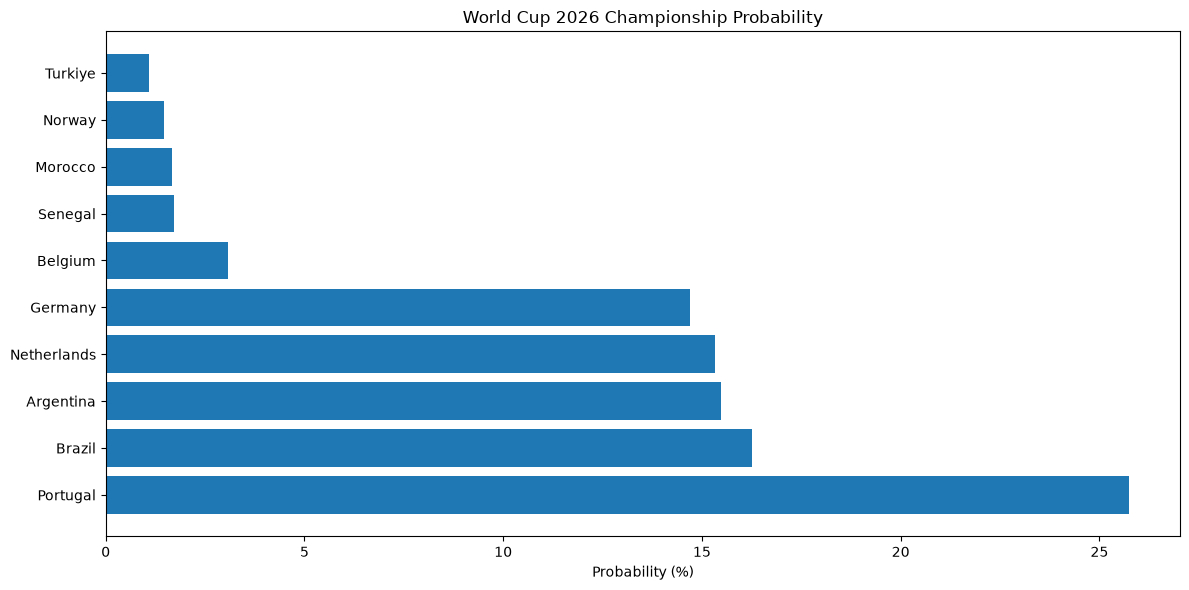

In [300]:
plt.figure(figsize=(12,6))

top10 = results_df.head(10)

plt.barh(
    top10["Team"],
    top10["Title Probability (%)"]
)

plt.xlabel("Probability (%)")
plt.title("World Cup 2026 Championship Probability")

plt.tight_layout()
plt.show()

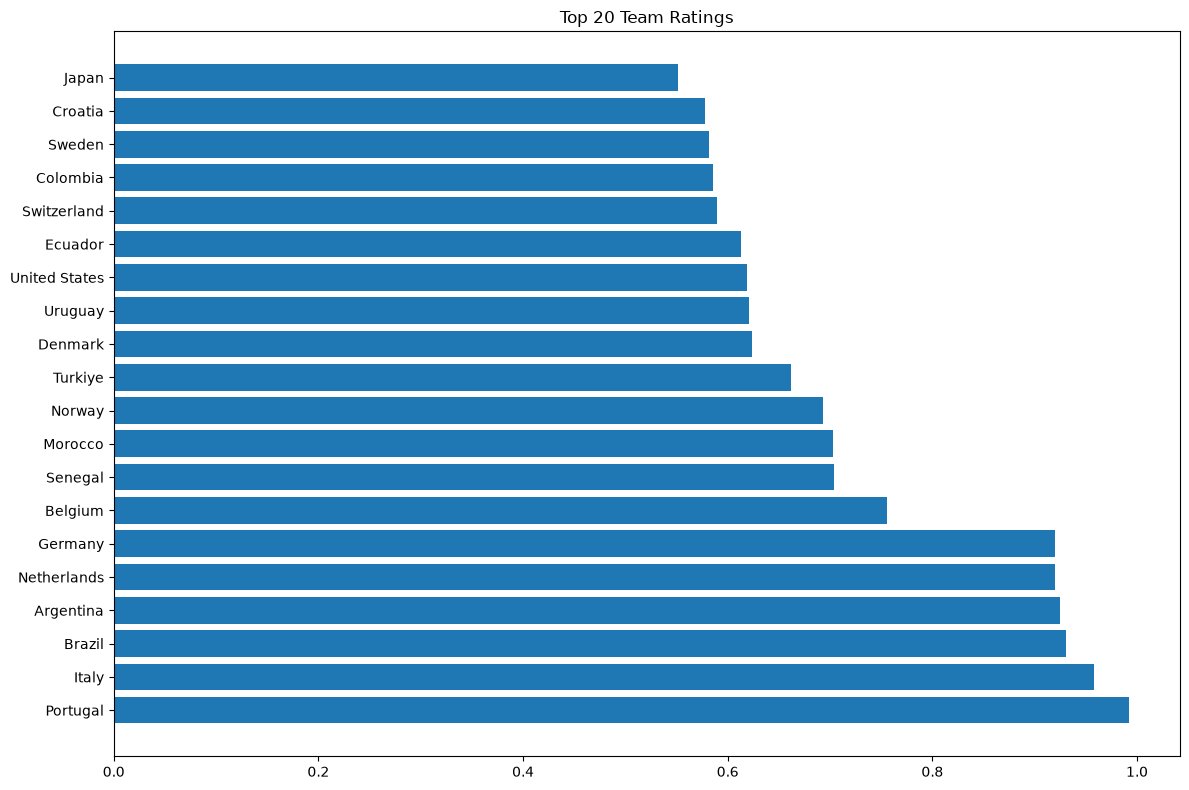

In [301]:
top20 = (
    df_ratings
    .sort_values(
        "team_rating",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top20["name"],
    top20["team_rating"]
)

plt.title("Top 20 Team Ratings")
plt.tight_layout()

plt.show()